# 01 · Data and calendars

**ORB study, notebook 1 of 5.** Question: is the data good enough to test an opening-range breakout on
Binance BTCUSDT and ETHUSDT perpetuals at one-minute resolution, before any strategy outcome is computed?

Frozen inputs: [PREREGISTRATION.md](PREREGISTRATION.md) section 2 (data, gate, Amendment A1),
`data/raw/binance_um/manifest.json`, `configs/calendar_*.json`. The gate result recorded before the first
outcome is `results/data_gate.json` (hashed into `results/freeze_F0.json`). This notebook recomputes the
checks from the panels and compares them with that record; it never rewrites it.

Re-create the inputs from the repository root with `venv\Scripts\python.exe studies\notebooks\orb_study\orb_data.py download`
then `... orb_data.py build` (about 290 MB of zips, 181 MB of panels).

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION.md").exists(), "execute from studies/notebooks/orb_study"
sys.path.insert(0, str(STUDY))
import orb_calendars as cal, orb_checks, orb_data, orb_engine as eng, orb_metrics as met, orb_policies as pol
from review_plots import AXIS, INK2, MUTED, NEGATIVE, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
RESULTS = STUDY / "results"

GATE = json.loads((RESULTS / "data_gate.json").read_text())
print("gate recorded", GATE["created_utc"], "| passed:", GATE["gate_passed"])

gate recorded 2026-09-15T07:36:56+00:00 | passed: True


## 1. What was downloaded

Every zip was checked against the SHA-256 in Binance's published `.CHECKSUM` file. Funding settlements after
the last monthly archive (2026-09-01 → cutoff) come from the public REST endpoint and are saved verbatim.

In [2]:
manifest = json.loads((STUDY / "data/raw/binance_um/manifest.json").read_text())
files = pd.DataFrame(manifest["files"])
print(manifest["source"], "| panel", manifest["panel_start_utc"], "->", manifest["cutoff_utc_exclusive"], "(exclusive)")
files.groupby(["symbol", "kind"]).agg(files=("file", "size"), megabytes=("bytes", lambda b: round(b.sum() / 1e6, 1)),
                                      checksums_verified=("checksum_ok", lambda c: bool(c.dropna().all()) if c.notna().any() else None))

Binance public data archive + public REST fundingRate | panel 2020-01-01T00:00:00+00:00 -> 2026-09-14T00:00:00+00:00 (exclusive)


files  megabytes checksums_verified
symbol  kind                                             
BTCUSDT funding          80        0.1               True
        funding_rest      1        0.0               None
        klines_1m        93      150.8               True
ETHUSDT funding          80        0.1               True
        funding_rest      1        0.0               None
        klines_1m        93      150.6               True

## 2. Panel integrity

A dense UTC minute grid from 2020-01-01 to 2026-09-14 (exclusive): 3,525,120 minutes per asset. Bars are
open-stamped, so the row at minute *t* covers [*t*, *t*+60 s) and is known at *t*+60 s.

In [3]:
rows = {}
for sym in orb_data.SYMBOLS:
    fresh = orb_checks.panel_integrity(sym)
    frozen = GATE[f"{sym}_panel"]
    rows[sym] = {k: v for k, v in fresh.items() if k not in ("outage_runs", "logical_sha256")}
    rows[sym]["matches_frozen_gate"] = fresh == frozen
pd.DataFrame(rows)

,BTCUSDT,ETHUSDT
minutes,3525120,3525120
present,3525120,3525120
duplicates,0,0
non_monotonic,0,0
off_grid,0,0
close_time_mismatch,0,0
timestamp_units,[ms],[ms]
non_finite,0,0
invalid_ohlc,0,0
outage_minutes,369,302


Every minute is present, but not every minute traded. The archive fills exchange outages with flat,
zero-volume bars. Those are not prices anyone could trade, so the engine treats every zero-volume bar as
missing. Most sit in runs of 13–99 minutes (Binance maintenance or incidents); ETH also has 24 isolated
tradeless minutes in 2020, when the contract was thin.

In [4]:
for sym in orb_data.SYMBOLS:
    runs = pd.DataFrame(GATE[f"{sym}_panel"]["outage_runs"])
    runs["year"] = runs.start_utc.str[:4]
    print(f"{sym}: {runs.minutes.sum()} tradeless minutes; runs longer than one minute:")
    display(runs[runs.minutes > 1].reset_index(drop=True))
    print("  isolated single tradeless minutes by year:", runs[runs.minutes == 1].groupby("year").size().to_dict())

BTCUSDT: 369 tradeless minutes; runs longer than one minute:


,start_utc,minutes,year
0,2020-09-27T11:13:00+00:00,2,2020
1,2021-03-02T01:01:00+00:00,59,2021
2,2022-05-01T22:26:00+00:00,29,2022
3,2022-05-28T16:40:00+00:00,35,2022
4,2023-09-12T08:34:00+00:00,19,2023
5,2023-11-10T15:07:00+00:00,99,2023
6,2024-10-28T16:21:00+00:00,14,2024
7,2024-10-28T20:00:00+00:00,74,2024
8,2025-01-14T13:32:00+00:00,2,2025
9,2025-01-29T01:23:00+00:00,13,2025


  isolated single tradeless minutes by year: {'2024': 1}
ETHUSDT: 302 tradeless minutes; runs longer than one minute:


,start_utc,minutes,year
0,2020-01-20T21:40:00+00:00,2,2020
1,2020-02-28T17:23:00+00:00,2,2020
2,2020-09-27T11:13:00+00:00,2,2020
3,2021-03-02T01:01:00+00:00,59,2021
4,2022-05-01T22:26:00+00:00,29,2022
5,2022-05-28T16:40:00+00:00,35,2022
6,2023-09-12T08:34:00+00:00,19,2023
7,2023-11-14T11:39:00+00:00,3,2023
8,2024-10-28T16:21:00+00:00,14,2024
9,2024-10-28T20:00:00+00:00,74,2024


  isolated single tradeless minutes by year: {'2020': 24, '2024': 1, '2025': 1}


## 3. Archive against the REST API

Two independent retrieval paths from the same exchange: our 1-minute archive aggregated to 15 minutes against
the project's REST-fetched perpetual tables (`cd_futures_15m`, `cd_futures_eth_15m`), and 1-minute bars against
`screener_klines_1m`. prod.db is opened read-only. The feed keeps writing, so a recomputation can differ slightly
from the frozen record; both are shown.

In [5]:
rows = []
for sym in orb_data.SYMBOLS:
    fresh, frozen = orb_checks.archive_vs_rest_15m(sym), GATE[f"{sym}_rest15m"]
    rows.append({"check": f"{sym} 15m vs {fresh['table']}", "overlap_bars": fresh["overlap_bars"],
                 "ohlc_disagree": fresh["ohlc_disagree"], "agree_share": round(fresh["ohlc_agree_share"], 6),
                 "frozen_ohlc_disagree": frozen["ohlc_disagree"], "volume_diff_gt_1pct": fresh["volume_rel_diff_gt_1pct"]})
fresh1, frozen1 = orb_checks.archive_vs_rest_1m(), GATE["BTCUSDT_rest1m"]
rows.append({"check": "BTCUSDT 1m vs screener_klines_1m", "overlap_bars": fresh1["overlap_bars"], "ohlc_disagree": fresh1["ohlc_disagree"],
             "agree_share": 1 - fresh1["ohlc_disagree"] / fresh1["overlap_bars"], "frozen_ohlc_disagree": frozen1["ohlc_disagree"],
             "volume_diff_gt_1pct": fresh1["volume_rel_diff_gt_1pct"]})
display(pd.DataFrame(rows))
print("Largest 15m disagreements (BTC) cluster on the outages:")
pd.DataFrame(GATE["BTCUSDT_rest15m"]["disagreements"][:10])

,check,overlap_bars,ohlc_disagree,agree_share,frozen_ohlc_disagree,volume_diff_gt_1pct
0,BTCUSDT 15m vs cd_futures_15m,235008,35,0.999851,35,33
1,ETHUSDT 15m vs cd_futures_eth_15m,199872,21,0.999895,21,23
2,BTCUSDT 1m vs screener_klines_1m,144000,0,1.000000,0,0


Largest 15m disagreements (BTC) cluster on the outages:


,utc,max_rel
0,2026-06-02T14:15:00+00:00,0.012718
1,2023-11-10T16:30:00+00:00,0.009489
2,2023-11-10T16:15:00+00:00,0.009085
3,2023-11-10T16:00:00+00:00,0.008161
4,2023-11-10T16:45:00+00:00,0.006701
5,2023-11-10T15:45:00+00:00,0.004693
6,2023-11-10T15:30:00+00:00,0.004558
7,2026-06-05T17:00:00+00:00,0.004347
8,2023-11-10T15:15:00+00:00,0.002371
9,2024-10-28T20:30:00+00:00,0.002334


## 4. Bars against trades (Amendment A1)

On three development days fixed by date rule (the 15th of June 2020, 2021 and 2022, 13:00–21:30 UTC) the
1-minute bars were rebuilt from Binance `aggTrades`. The first run failed the clause as originally written,
"exact agreement": Binance sets some bar opens to the **previous bar's close** instead of the first trade (every
mismatched open equals the previous close, one tick from a trade printed 5–105 ms after the boundary), and a
few boundary trades land in the adjacent minute. The archive matches the REST API exactly, so this is how the
exchange builds bars. The clause was amended **before any outcome** (PREREGISTRATION.md section 2). The frozen
results are shown; set `RECHECK = True` to download the three days again (about 130 MB).

In [6]:
RECHECK = False
agg = [orb_checks.trades_vs_bars(d) for d in orb_checks.AGG_DAYS] if RECHECK else GATE["BTCUSDT_aggtrades"]
pd.DataFrame([{k: v for k, v in a.items() if k != "source"} for a in agg])

,day,symbol,zip_bytes,trade_minutes,expected_minutes,ohlc_disagree_by_field,open_unexplained,high_low_disagree,high_low_max_diff_bp,volume_max_rel_diff,window_volume_rel_diff
0,2020-06-15,BTCUSDT,10420909,510,510,"{'open': 11, 'high': 0, 'low': 0, 'close': 0}",0,0,0.000000,0.004696,0.0
1,2021-06-15,BTCUSDT,39559512,510,510,"{'open': 85, 'high': 2, 'low': 2, 'close': 0}",0,4,0.383132,0.013557,0.0
2,2022-06-15,BTCUSDT,78670063,510,510,"{'open': 111, 'high': 1, 'low': 0, 'close': 0}",0,1,0.048685,0.011686,0.0


## 5. Funding and tick size

Funding settles every 8 hours on both contracts throughout 2020–2026, with no missing settlement. The chart is
context for the exit arms that hold overnight (longs pay a positive rate).

,BTCUSDT,ETHUSDT
rows,7344.000000,7344.000000
expected_slots,7344.000000,7344.000000
unique_slots,7344.000000,7344.000000
missing_slots,0.000000,0.000000
max_offset_ms,47.000000,47.000000
rate_min,-0.003000,-0.003563
rate_max,0.003000,0.003750
rate_mean_bp,1.074513,1.268931
from_rest,39.000000,39.000000


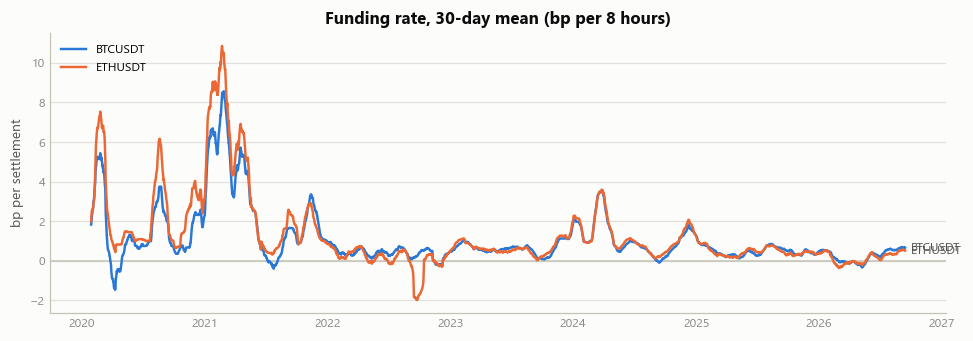

In [7]:
display(pd.DataFrame({s: GATE[f"{s}_funding"] for s in orb_data.SYMBOLS}))
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, sym in enumerate(orb_data.SYMBOLS):
    f = orb_data.load_funding(sym)
    s = pd.Series(f["rate"] * 1e4, index=pd.to_datetime(f["time_ms"], unit="ms")).rolling(90).mean()
    ax.plot(s.index, s.values, color=SERIES[i], label=sym)
    ax.annotate(sym, xy=(s.index[-1], s.values[-1]), xytext=(4, 0), textcoords="offset points", fontsize=8, color=INK2, va="center")
style(ax); zero_line(ax)
ax.set_title("Funding rate, 30-day mean (bp per 8 hours)"); ax.set_ylabel("bp per settlement"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [8]:
p = orb_data.load_panel("BTCUSDT")
months = pd.to_datetime(p["t0_ms"] + np.arange(len(p["close"])) * 60_000, unit="ms").strftime("%Y-%m")
on_grid = np.abs(np.round(p["close"] * 10) - p["close"] * 10) < 1e-6
share = pd.Series(on_grid).groupby(months).mean()
print("BTCUSDT share of 1m closes on a 0.1 grid (tick 0.01 before, 0.10 from 2022-02-15):")
share.loc["2021-11":"2022-05"].round(3).to_frame("share_on_0.1_grid").T

BTCUSDT share of 1m closes on a 0.1 grid (tick 0.01 before, 0.10 from 2022-02-15):


,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05
share_on_0.1_grid,0.147,0.15,0.162,0.576,1.0,1.0,1.0


## 6. Calendars and eligible sessions

NY sessions are full-length NYSE days at 09:30 America/New_York; London sessions full-length LSE days at 08:00
Europe/London; the UTC anchor is every calendar day. `tests/test_calendars.py` checks the frozen calendars against
an independently compiled NYSE holiday and early-close list and the DST behaviour of the anchors.

In [9]:
r = subprocess.run([sys.executable, "-m", "pytest", "tests/test_calendars.py", "-q", "-p", "no:cacheprovider"],
                   capture_output=True, text=True, cwd=STUDY)
print(r.stdout.strip().splitlines()[-1])
ny = cal.sessions("NY", "2024-03-04", "2024-04-05")
ny["t0_utc"] = pd.to_datetime(ny.t0_ms, unit="ms").dt.strftime("%H:%M")
print("Around the 2024 DST changes (US 03-10, UK 03-31): the NY anchor moves in UTC; the gap to London is -4h between them")
ny[["date", "t0_utc", "ny_minus_ldn_hours"]].iloc[[3, 4, 5, 18, 19, 20]]

5 passed in 0.61s
Around the 2024 DST changes (US 03-10, UK 03-31): the NY anchor moves in UTC; the gap to London is -4h between them


,date,t0_utc,ny_minus_ldn_hours
3,2024-03-07,14:30,-5.0
4,2024-03-08,14:30,-5.0
5,2024-03-11,13:30,-4.0
18,2024-03-28,13:30,-4.0
19,2024-04-01,13:30,-5.0
20,2024-04-02,13:30,-5.0


In [10]:
for key, table in GATE["eligibility"].items():
    if key.startswith("BTCUSDT"):
        print(key)
        display(pd.DataFrame(table).set_index("year"))

BTCUSDT_NY


,ok,sessions,outage_in_horizon,early_close_excluded
year,,,,
2020,251,251,0,2
2021,251,251,0,1
2022,250,250,0,1
2023,248,248,1,2
2024,249,249,1,3
2025,247,247,0,3
2026,174,174,0,0


BTCUSDT_LDN


,ok,sessions,outage_in_horizon,early_close_excluded
year,,,,
2020,252,252,0,2
2021,251,251,0,2
2022,248,248,0,2
2023,249,249,1,2
2024,252,252,0,2
2025,251,251,1,2
2026,176,176,0,0


BTCUSDT_UTC


,ok,sessions,outage_in_horizon,early_close_excluded
year,,,,
2020,366,366,0,0
2021,365,365,1,0
2022,365,365,0,0
2023,365,365,0,0
2024,366,366,0,0
2025,365,365,2,0
2026,256,256,0,0


## Gate result

Every clause passed before the first outcome was computed. "ok" sessions have a complete 15-minute opening
range; `outage_in_horizon` counts sessions with tradeless minutes somewhere between the anchor and the session
exit, which the engine handles with its gap rules (and flags).

In [11]:
pd.Series(GATE["gate"], name="passed").to_frame()

,passed
grid_and_duplicates,True
ohlc_valid,True
rest15m_agree_999,True
aggtrades_consistent,True
funding_complete,True
